In [1]:
!pip install geopy


   ---------------------------------------- 2/2 [geopy]



In [2]:
import numpy as np
from astropy.coordinates import EarthLocation, AltAz, ITRS
from astropy.time import Time
import astropy.units as u
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from geopy.distance import geodesic
from scipy.optimize import least_squares
# -------------------------------
# CONSTANTS
# -------------------------------
c = 3e8
k = 1.38e-23
T_sys = 100

mpl.rcParams['xtick.labelsize'] = 18

# -------------------------------
# RADAR PARAMETERS (given)
# -------------------------------
aries_radar = {
    "lat": 29.4,
    "lon": 79.5,
    "height": 1793,
    "freq": 206.5e6,
    "bandwidth": 5e6,
    "Pt": 235e3,
    "gain_dBi": 34
}

mst_radar = {
    "lat": 13.47,
    "lon": 79.18,
    "height": 370,
    "freq": 53e6,
    "bandwidth": 5e6,
    "Pt": 2.5e6,
    "gain_dBi": 36
}


lam1 = c / aries_radar["freq"]
lam2 = c / mst_radar["freq"]

#Gt_dBi = 34   # transmitter gain (given radar)
Gr_dBi = 15   # receiver gain (you can change this)

Gt1 = 10**(aries_radar["gain_dBi"]/10)
Gt2 = 10**(mst_radar["gain_dBi"]/10)
Gr = 10**(Gr_dBi/10)

pulse_widths_aries = [8e-6, 16e-6, 32e-6, 64e-6]
prfs_aries = [250, 1000, 4000, 8000]

pulse_widths_gadanki = [1e-6, 8e-6, 16e-6, 32e-6]
prfs_gadanki = [62.5, 250, 1000, 4000, 8000]

integration_times = [0.01, 0.1, 1.0]

ranges = [300e3, 500e3, 1000e3]

# -------------------------------
# UTILITY FUNCTIONS
# -------------------------------
def ecef_from_location(loc, t):
    return loc.get_itrs(obstime=t).cartesian.xyz.to(u.m).value

def unit_vector(v):
    return v / np.linalg.norm(v)

# -------------------------------
# GEOMETRY
# -------------------------------
def multistatic_geometry(tx1_loc, tx2_loc, rx_loc, tgt_loc, t):

    tx1 = ecef_from_location(tx1_loc, t)
    tx2 = ecef_from_location(tx2_loc, t)
    rx = ecef_from_location(rx_loc, t)
    tgt = ecef_from_location(tgt_loc, t)

    Rt1_vec = tgt - tx1
    Rt2_vec = tgt - tx2
    Rr_vec = tgt - rx

    Rt1 = np.linalg.norm(Rt1_vec)
    Rt2 = np.linalg.norm(Rt2_vec)
    Rr = np.linalg.norm(Rr_vec)

    return (
        Rt1,
        Rt2,
        Rr,
        unit_vector(Rt1_vec),
        unit_vector(Rt2_vec),
        unit_vector(Rr_vec)
    )

# =========================================================
# MULTISTATIC RADAR EQUATION
# =========================================================
def received_power_multistatic(Pt1, Gt1, Pt2, Gt2, Gr, lam1, lam2, sigma, Rt1, Rt2, Rr):
    Pr1 = ( Pt1 * Gt1 * Gr * lam1**2 * sigma ) / ( (4*np.pi)**3 * Rt1**2 * Rr**2 )
    Pr2 = ( Pt2 * Gt2 * Gr * lam2**2 * sigma ) / ( (4*np.pi)**3 * Rt2**2 * Rr**2 )
    return Pr1, Pr2

# =========================================================
# PROCESSING GAIN
# =========================================================
def processing_gain(tau, B, PRF, T_int):
    return (tau * B) * (PRF * T_int)

# =========================================================
# NOISE POWER
# =========================================================
def noise_power(tau):
    B_eff = 1 / tau
    return k * T_sys * B_eff

# =========================================================
# MULTISTATIC DOPPLER
# =========================================================

def multistatic_doppler( v_vec, u_t1, u_t2, u_r, lam1, lam2):
    fD1 = np.dot(v_vec, (u_t1 + u_r)) / lam1
    fD2 = np.dot(v_vec, (u_t2 + u_r)) / lam2
    return fD1, fD2
    
# =========================================================
# BISTATIC ANGLE
# =========================================================

def bistatic_angle(tx_loc, rx_loc, tgt_loc, t):
    # ECEF coordinates
    tx = tx_loc.get_itrs(obstime=t).cartesian.xyz.to(u.m).value
    rx = rx_loc.get_itrs(obstime=t).cartesian.xyz.to(u.m).value
    tgt = tgt_loc.get_itrs(obstime=t).cartesian.xyz.to(u.m).value

    # Direction vectors
    Rt_vec = tgt - tx
    Rr_vec = tgt - rx

    # Unit vectors
    u_t = Rt_vec / np.linalg.norm(Rt_vec)
    u_r = Rr_vec / np.linalg.norm(Rr_vec)

    # Bistatic angle
    cos_beta = np.dot(u_t, u_r)
    beta = np.degrees(np.arccos(cos_beta))

    return beta

# -------------------------------
# MAIN
# -------------------------------

t = Time('2026-04-20 00:00:00') #Time.now()

# =========================================================
# TRANSMITTER LOCATIONS
# =========================================================

tx1_loc = EarthLocation( lat=aries_radar["lat"] * u.deg, lon=aries_radar["lon"] * u.deg, height=aries_radar["height"] * u.m)
tx2_loc = EarthLocation( lat=mst_radar["lat"] * u.deg, lon=mst_radar["lon"] * u.deg, height=mst_radar["height"] * u.m )

# =========================================================
# RECEIVER LOCATION IIT KANPUR
# =========================================================
rx_loc = EarthLocation( lat=26.4499 * u.deg, lon=80.3319 * u.deg, height=137 * u.m )

# =========================================================
# BASELINES
# =========================================================
baseline1 = geodesic((tx1_loc.lat.value, tx1_loc.lon.value), (rx_loc.lat.value, rx_loc.lon.value)).meters
baseline2 = geodesic((tx2_loc.lat.value, tx2_loc.lon.value), (rx_loc.lat.value, rx_loc.lon.value)).meters

print(f"ARIES → IITK baseline = {baseline1/1e3:.1f} km")
print(f"Gadanki → IITK baseline = {baseline2/1e3:.1f} km")

# =========================================================
# TARGET LOCATION
# =========================================================
tgt_lat = 24.0
tgt_lon = 80.0

sigma_test = 1e-3

print("\n=== MULTISTATIC RADAR SIMULATION ===")

# =========================================================
# MAIN LOOP
# =========================================================
for R_alt in ranges:

    tgt_loc = EarthLocation( lat=tgt_lat * u.deg, lon=tgt_lon * u.deg, height=R_alt * u.m )
    Rt1, Rt2, Rr, u_t1, u_t2, u_r = multistatic_geometry( tx1_loc, tx2_loc, rx_loc, tgt_loc, t )

    print(f"\n--- Target altitude: {R_alt/1e3:.0f} km ---")
    print(f"ARIES → Target = {Rt1/1e3:.1f} km")
    print(f"Gadanki → Target = {Rt2/1e3:.1f} km")
    print(f"Target → IITK = {Rr/1e3:.1f} km")

    # =====================================================
    # SATELLITE VELOCITY
    # =====================================================
    v_mag = 7500
    v_vec = v_mag * np.array([0, 1, 0])

    # =====================================================
    # DOPPLERS
    # =====================================================
    fD1, fD2 = multistatic_doppler( v_vec, u_t1, u_t2, u_r, lam1, lam2 )
    
    print(f"ARIES Doppler ≈ {fD1/1e3:.1f} kHz")
    print(f"Gadanki Doppler ≈ {fD2/1e3:.1f} kHz")

    # =====================================================
    # BISTATIC ANGLES
    # =====================================================
    
    beta1 = bistatic_angle( tx1_loc, rx_loc, tgt_loc, t )
    beta2 = bistatic_angle( tx2_loc, rx_loc, tgt_loc, t )

    print(f"ARIES bistatic angle ≈ {beta1:.1f}°")
    print(f"Gadanki bistatic angle ≈ {beta2:.1f}°")

    # =====================================================
    # PULSE/PULSE REPETITION LOOPS
    # =====================================================
    for tau1 in pulse_widths_aries:
        for prf1 in prfs_aries:
            for tau2 in pulse_widths_gadanki:
                for prf2 in prfs_gadanki:
                    for T_int in integration_times:
                        # =================================
                        # RECEIVED POWERS
                        # =================================
                        Pr1, Pr2 = received_power_multistatic( aries_radar["Pt"],Gt1,mst_radar["Pt"],Gt2,Gr,lam1,lam2,sigma_test,Rt1,Rt2,Rr)

                        # =================================
                        # PROCESSING GAINS
                        # =================================
                        Gp1 = processing_gain(tau1,aries_radar["bandwidth"],prf1,T_int)
                        Gp2 = processing_gain(tau2,mst_radar["bandwidth"],prf2,T_int)

                        # =================================
                        # NOISE POWERS
                        # =================================
                        Pn1 = noise_power(tau1)
                        Pn2 = noise_power(tau2)

                        # =================================
                        # INDIVIDUAL SNRs
                        # =================================
                        SNR1 = (Pr1 * Gp1) / Pn1
                        SNR2 = (Pr2 * Gp2) / Pn2

                        # =================================
                        # TOTAL MULTISTATIC SNR
                        # =================================
                        SNR_total = SNR1 + SNR2
                        print(
                            f"ARIES: tau={tau1*1e6:>5.0f}us "
                            f"PRF={prf1:>6} | "
                            f"Gadanki: tau={tau2*1e6:>5.0f}us "
                            f"PRF={prf2:>6} | "
                            f"T={T_int:.2f}s → "
                            f"SNR={10*np.log10(SNR_total):6.1f} dB"
                        )

ARIES → IITK baseline = 337.0 km
Gadanki → IITK baseline = 1442.0 km

=== MULTISTATIC RADAR SIMULATION ===

--- Target altitude: 300 km ---
ARIES → Target = 682.8 km
Gadanki → Target = 1231.4 km
Target → IITK = 410.1 km
ARIES Doppler ≈ 8.9 kHz
Gadanki Doppler ≈ 1.1 kHz
ARIES bistatic angle ≈ 21.6°
Gadanki bistatic angle ≈ 112.5°
ARIES: tau=    8us PRF=   250 | Gadanki: tau=    1us PRF=  62.5 | T=0.01s → SNR=  -7.2 dB
ARIES: tau=    8us PRF=   250 | Gadanki: tau=    1us PRF=  62.5 | T=0.10s → SNR=   2.8 dB
ARIES: tau=    8us PRF=   250 | Gadanki: tau=    1us PRF=  62.5 | T=1.00s → SNR=  12.8 dB
ARIES: tau=    8us PRF=   250 | Gadanki: tau=    1us PRF=   250 | T=0.01s → SNR=  -4.9 dB
ARIES: tau=    8us PRF=   250 | Gadanki: tau=    1us PRF=   250 | T=0.10s → SNR=   5.1 dB
ARIES: tau=    8us PRF=   250 | Gadanki: tau=    1us PRF=   250 | T=1.00s → SNR=  15.1 dB
ARIES: tau=    8us PRF=   250 | Gadanki: tau=    1us PRF=  1000 | T=0.01s → SNR=  -0.6 dB
ARIES: tau=    8us PRF=   250 | Gadanki

In [25]:
# =========================================================
# MULTISTATIC GEOMETRY PLOT
# =========================================================
def plot_multistatic_geometry(tx1_loc, tx2_loc, rx_loc, t):
    rx = rx_loc.get_itrs(obstime=t).cartesian.xyz.value
    tx1 = tx1_loc.get_itrs(obstime=t).cartesian.xyz.value
    tx2 = tx2_loc.get_itrs(obstime=t).cartesian.xyz.value

    lat = rx_loc.lat.rad
    lon = rx_loc.lon.rad

    east = np.array([-np.sin(lon),np.cos(lon),0])
    north = np.array([-np.sin(lat) * np.cos(lon),-np.sin(lat) * np.sin(lon), np.cos(lat)])

    def azimuth(vec):
        e = np.dot(vec, east)
        n = np.dot(vec, north)
        return np.arctan2(e, n)

    vec1 = tx1 - rx
    vec2 = tx2 - rx

    az1 = azimuth(vec1)
    az2 = azimuth(vec2)

    #plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # IITK RECEIVER
    ax.scatter(0,0,s=150,label="IIT Kanpur Rx")
    # ARIES
    ax.scatter(az1,1.0,s=120,label="ARIES Tx")

    # GADANKI
    ax.scatter(az2,1.0,s=120,label="Gadanki MST Tx")
    ax.set_rticks([])
    ax.set_title("Multistatic Geometry")
    ax.legend()
    plt.show()

In [26]:
# =========================================================
# ARRAY GAIN
# =========================================================
def array_gain_yagi(num_elements, element_gain_dBi, loss_dB=2):

    G_elem = 10**(element_gain_dBi/10)
    G_array = num_elements * G_elem
    G_array_eff = G_array * 10**(-loss_dB/10)
    return (10*np.log10(G_array_eff), G_array_eff)

# =========================================================
# EXAMPLE RECEIVER ARRAY
# =========================================================
Gr_dBi, Gr = array_gain_yagi(16, 7, loss_dB=2)
print(f"\nReceiver gain ≈ {Gr_dBi:.1f} dBi")


Receiver gain ≈ 17.0 dBi


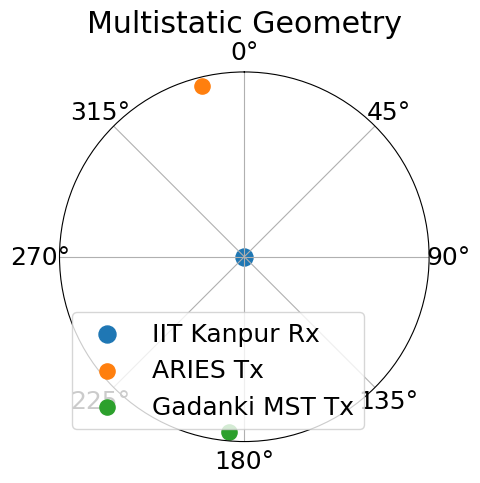

In [27]:
# =========================================================
# PLOT GEOMETRY
# =========================================================
plot_multistatic_geometry(tx1_loc, tx2_loc, rx_loc, t)

In [28]:
# =========================================================
# MULTISTATIC SNR vs PRF
# =========================================================
def plot_snr_vs_prf_multistatic(sigma, Rt1, Rt2, Rr, tau1, tau2, B1, B2, T_int):
    prfs = np.linspace(100, 10000, 50)
    snr_list = []
    for prf in prfs:

        # =============================================
        # RECEIVED POWERS
        # =============================================
        Pr1, Pr2 = received_power_multistatic(aries_radar["Pt"],Gt1,mst_radar["Pt"],Gt2,Gr,lam1,lam2,sigma,Rt1,Rt2,Rr)

        # =============================================
        # PROCESSING GAINS
        # =============================================
        Gp1 = processing_gain(tau1,B1,prf,T_int)
        Gp2 = processing_gain(tau2,B2,prf,T_int)

        # =============================================
        # NOISE POWERS
        # =============================================
        Pn1 = noise_power(tau1)
        Pn2 = noise_power(tau2)

        # =============================================
        # INDIVIDUAL SNRs
        # =============================================
        SNR1 = (Pr1 * Gp1) / Pn1
        SNR2 = (Pr2 * Gp2) / Pn2

        # =============================================
        # TOTAL MULTISTATIC SNR
        # =============================================
        SNR_total = SNR1 + SNR2
        snr_list.append(10*np.log10(SNR_total))

    plt.figure()
    plt.semilogx(prfs,snr_list)

    plt.xlabel("PRF (Hz)")
    plt.ylabel("SNR (dB)")
    plt.title("Multistatic SNR vs PRF")
    plt.grid()

    plt.show()
    
# =========================================================
# MULTISTATIC SNR vs tau
# =========================================================
def plot_snr_vs_tau_multistatic(sigma,Rt1,Rt2,Rr,prf1,prf2,B1,B2,T_int):
    taus = np.linspace(1e-6, 100e-6, 50)
    snr_list = []
    for tau in taus:
        # =============================================
        # RECEIVED POWERS
        # =============================================
        Pr1, Pr2 = received_power_multistatic(aries_radar["Pt"],Gt1,mst_radar["Pt"],Gt2,Gr,lam1,lam2,sigma,Rt1,Rt2,Rr)

        # =============================================
        # PROCESSING GAINS
        # =============================================
        Gp1 = processing_gain(tau,B1,prf1,T_int)
        Gp2 = processing_gain(tau,B2,prf2,T_int)

        # =============================================
        # NOISE POWERS
        # =============================================
        Pn1 = noise_power(tau)
        Pn2 = noise_power(tau)

        # =============================================
        # INDIVIDUAL SNRs
        # =============================================
        SNR1 = (Pr1 * Gp1) / Pn1
        SNR2 = (Pr2 * Gp2) / Pn2

        # =============================================
        # TOTAL SNR
        # =============================================
        SNR_total = SNR1 + SNR2
        snr_list.append(10*np.log10(SNR_total))

    plt.figure()
    plt.plot(taus * 1e6,snr_list)
    plt.xlabel("Pulse Width (µs)")
    plt.ylabel("SNR (dB)")
    plt.title("Multistatic SNR vs Pulse Width")
    plt.grid()

    plt.show()
    
# =========================================================
# MULTISTATIC SNR vs RCS
# =========================================================
def plot_snr_vs_rcs_multistatic(Rt1,Rt2,Rr,tau1,tau2,prf1,prf2,B1,B2,T_int):
    rcs_vals = np.logspace(-8, 0, 100)
    snr_list = []
    for sigma in rcs_vals:
        # =============================================
        # RECEIVED POWERS
        # =============================================
        Pr1, Pr2 = received_power_multistatic(aries_radar["Pt"],Gt1,mst_radar["Pt"],Gt2,Gr,lam1,lam2,sigma,Rt1,Rt2,Rr)

        # =============================================
        # PROCESSING GAINS
        # =============================================
        Gp1 = processing_gain(tau1,B1,prf1,T_int)
        Gp2 = processing_gain(tau2,B2,prf2,T_int)

        # =============================================
        # NOISE POWERS
        # =============================================
        Pn1 = noise_power(tau1)
        Pn2 = noise_power(tau2)

        # =============================================
        # INDIVIDUAL SNRs
        # =============================================
        SNR1 = (Pr1 * Gp1) / Pn1
        SNR2 = (Pr2 * Gp2) / Pn2

        # =============================================
        # TOTAL SNR
        # =============================================
        SNR_total = SNR1 + SNR2
        snr_list.append(10*np.log10(SNR_total))

    snr_array = np.array(snr_list)
    
    plt.figure()
    ax = plt.gca()
    ax.semilogx(rcs_vals,snr_array,label="SNR")

    threshold = 10
    
    ax.axhline(threshold,linestyle='--',label="10 dB threshold")

    ax.axhspan(-50,threshold,alpha=0.3)

    ax.set_xlabel("RCS (m²)",fontsize=18)

    ax.set_ylabel("SNR (dB)",fontsize=18)
    ax.grid()
    ax.legend()
    plt.show()

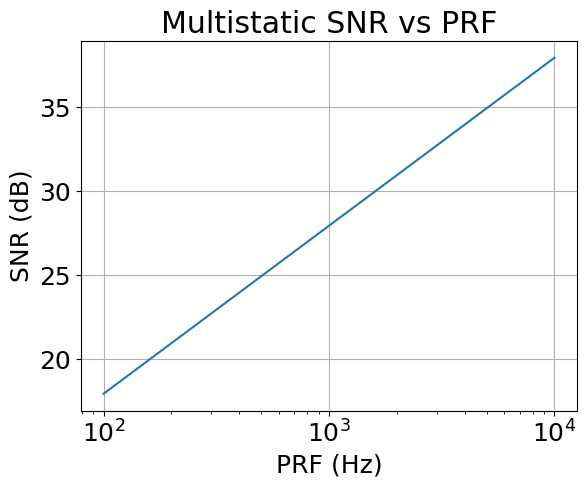

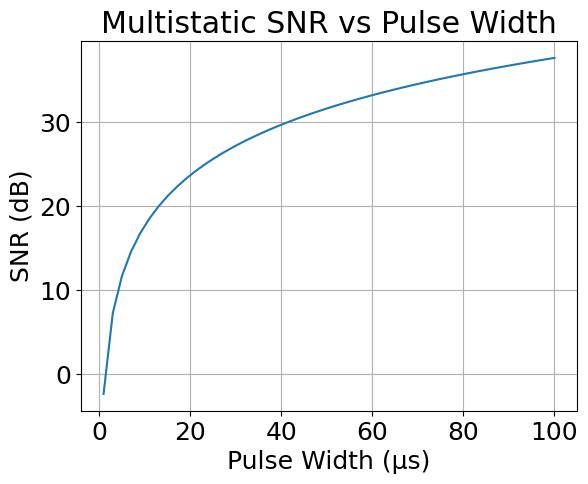

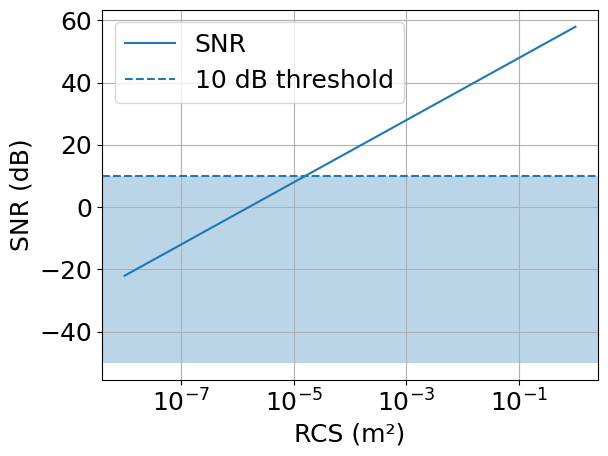

In [29]:
# =========================================================
# PARAMETERS
# =========================================================
sigma = 1e-3
tau1 = 64e-6      # ARIES pulse width
tau2 = 32e-6      # Gadanki pulse width
prf1 = 1000       # ARIES PRF
prf2 = 1000       # Gadanki PRF
rcs_vals = np.logspace(-8, 0, 100)

plot_snr_vs_prf_multistatic(sigma=sigma,Rt1=Rt1,Rt2=Rt2,Rr=Rr,tau1=tau1,tau2=tau2,B1=aries_radar["bandwidth"],B2=mst_radar["bandwidth"],T_int=0.1)
plot_snr_vs_tau_multistatic(sigma=sigma,Rt1=Rt1,Rt2=Rt2,Rr=Rr,prf1=prf1,prf2=prf2,B1=aries_radar["bandwidth"],B2=mst_radar["bandwidth"],T_int=0.1)
plot_snr_vs_rcs_multistatic(Rt1=Rt1,Rt2=Rt2,Rr=Rr,tau1=tau1,tau2=tau2,prf1=prf1,prf2=prf2,B1=aries_radar["bandwidth"],B2=mst_radar["bandwidth"],T_int=0.1)

In [30]:
# =========================================================
# SPACE DEBRIS RCS PDF
# =========================================================
def debris_rcs_pdf(rcs_vals,mu=-5,sigma=1.5):
    """
    Log-normal PDF in log10(RCS) space

    mu     : mean log10(RCS)
    sigma  : standard deviation
    """
    log_rcs = np.log10(rcs_vals)
    pdf = (1 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((log_rcs - mu)/sigma)**2)
    return pdf

# =========================================================
# PLOT RCS PDF
# =========================================================
def plot_rcs_pdf():
    rcs_vals = np.logspace(-8, 0, 500)
    pdf = debris_rcs_pdf(rcs_vals)
    plt.figure(figsize=(8,5))
    plt.semilogx(rcs_vals,pdf,linewidth=2)

    plt.xlabel("RCS (m²)")
    plt.ylabel("Probability Density")
    plt.title("Space Debris RCS Distribution")
    plt.grid()
    
    plt.show()


In [31]:
# =========================================================
# MULTISTATIC SNR + RCS PDF
# =========================================================
def plot_snr_with_pdf_multistatic(Rt1,Rt2,Rr,tau1,tau2,prf1,prf2,B1,B2,T_int):

    # =====================================================
    # RCS VALUES
    # =====================================================
    rcs_vals = np.logspace(-8, 0, 500)
    # =====================================================
    # COMPUTE MULTISTATIC SNR
    # =====================================================
    snr_list = []
    for sigma in rcs_vals:
        # -------------------------------------------------
        # RECEIVED POWERS
        # -------------------------------------------------
        Pr1, Pr2 = received_power_multistatic(aries_radar["Pt"],Gt1,mst_radar["Pt"],Gt2,Gr,lam1,lam2,sigma,Rt1,Rt2,Rr)
        # -------------------------------------------------
        # PROCESSING GAINS
        # -------------------------------------------------
        Gp1 = processing_gain(tau1,B1,prf1,T_int)
        Gp2 = processing_gain(tau2,B2,prf2,T_int)

        # -------------------------------------------------
        # NOISE POWERS
        # -------------------------------------------------
        Pn1 = noise_power(tau1)
        Pn2 = noise_power(tau2)

        # -------------------------------------------------
        # INDIVIDUAL SNRs
        # -------------------------------------------------
        SNR1 = (Pr1 * Gp1) / Pn1
        SNR2 = (Pr2 * Gp2) / Pn2

        # -------------------------------------------------
        # TOTAL MULTISTATIC SNR
        # -------------------------------------------------
        SNR_total = SNR1 + SNR2
        snr_list.append(10*np.log10(SNR_total))

    snr_array = np.array(snr_list)

    # =====================================================
    # RCS PDF
    # =====================================================
    pdf = debris_rcs_pdf(rcs_vals)

    # =====================================================
    # PLOT
    # =====================================================
    fig, ax1 = plt.subplots(figsize=(8,5))

    # -----------------------------------------------------
    # SNR AXIS
    # -----------------------------------------------------
    ax1.semilogx(rcs_vals,snr_array,label="SNR (dB)")
    ax1.set_xlabel("RCS (m²)")
    ax1.set_ylabel("SNR (dB)")
    ax1.set_ylim(0, 70)
    ax1.set_xlim(1e-8, 1)

    ax1.grid()

    # -----------------------------------------------------
    # DETECTION REGION
    # -----------------------------------------------------
    threshold = 10
    ax1.axhline(threshold,linestyle='--',label="10 dB Threshold")

    ax1.fill_between(rcs_vals,0,100,where=(snr_array > threshold),alpha=0.2)

    # =====================================================
    # PDF AXIS
    # =====================================================
    ax2 = ax1.twinx()

    ax2.semilogx(rcs_vals,pdf,linestyle='--',label="PDF")
    ax2.set_ylabel("Probability Density")

    # =====================================================
    # COMBINED LEGEND
    # =====================================================
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(lines_1 + lines_2,labels_1 + labels_2)
    plt.title("Multistatic SNR vs RCS with Debris Distribution")
    plt.show()

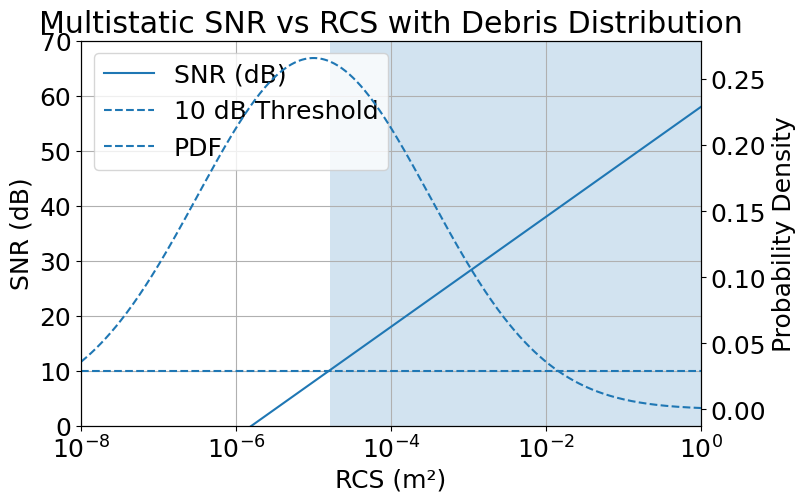

In [32]:
# =========================================================
# PARAMETERS
# =========================================================
sigma = 1e-3
tau1 = 64e-6      # ARIES pulse width
tau2 = 32e-6      # Gadanki pulse width
prf1 = 1000       # ARIES PRF
prf2 = 1000       # Gadanki PRF

# =========================================================
# MULTISTATIC SNR + PDF PLOT
# =========================================================
plot_snr_with_pdf_multistatic(Rt1=Rt1,Rt2=Rt2,Rr=Rr,tau1=tau1,tau2=tau2,prf1=prf1,prf2=prf2,B1=aries_radar["bandwidth"],B2=mst_radar["bandwidth"],T_int=0.1)

In [33]:
# =========================================================
# MULTISTATIC BISTATIC ANGLE vs ALTITUDE
# =========================================================
def plot_bistatic_angle_vs_altitude_multistatic(tx1_loc,tx2_loc,rx_loc):
    t = Time.now()
    # Target altitudes
    alts = np.linspace(200e3, 1500e3, 50)
    # Store bistatic angles
    betas1 = []
    betas2 = []
    for h in alts:
        # =============================================
        # TARGET LOCATION
        # =============================================
        tgt_loc = EarthLocation(lat=tx1_loc.lat,lon=tx1_loc.lon,height=tx1_loc.height + h*u.m)

        # =============================================
        # ARIES BISTATIC ANGLE
        # =============================================
        beta1 = bistatic_angle(tx1_loc,rx_loc,tgt_loc,t)
        # =============================================
        # GADANKI BISTATIC ANGLE
        # =============================================
        beta2 = bistatic_angle(tx2_loc,rx_loc,tgt_loc,t)

        betas1.append(beta1)
        betas2.append(beta2)

    # =================================================
    # PLOT
    # =================================================
    plt.figure(figsize=(8,5))

    plt.plot(alts/1e3,betas1,linewidth=2,label="ARIES")
    plt.plot(alts/1e3,betas2,linewidth=2,label="Gadanki MST")

    plt.xlabel("Target altitude (km)")
    plt.ylabel("Bistatic angle (deg)")
    plt.title("Bistatic Angle vs Altitude")

    # Reference lines
    plt.axhline(90,linestyle='--')
    plt.axhline(180,linestyle='--')
    plt.grid()
    plt.legend()
    plt.show()

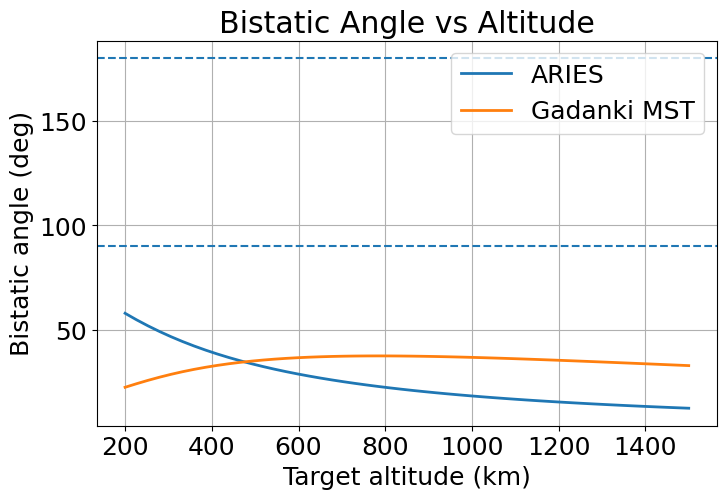

In [34]:
plot_bistatic_angle_vs_altitude_multistatic(tx1_loc,tx2_loc,rx_loc)

=== LOCALIZATION RESULTS ===
True target position      : [120. 250.] km
Bistatic estimate         : [202.17927416  94.18317908] km
Multistatic estimate      : [119.66946694 249.33304034] km
Bistatic localization error    = 176159.9 m
Multistatic localization error = 744.4 m


C:\Users\Anunnya\AppData\Local\Temp\ipykernel_14572\1465022661.py:136: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


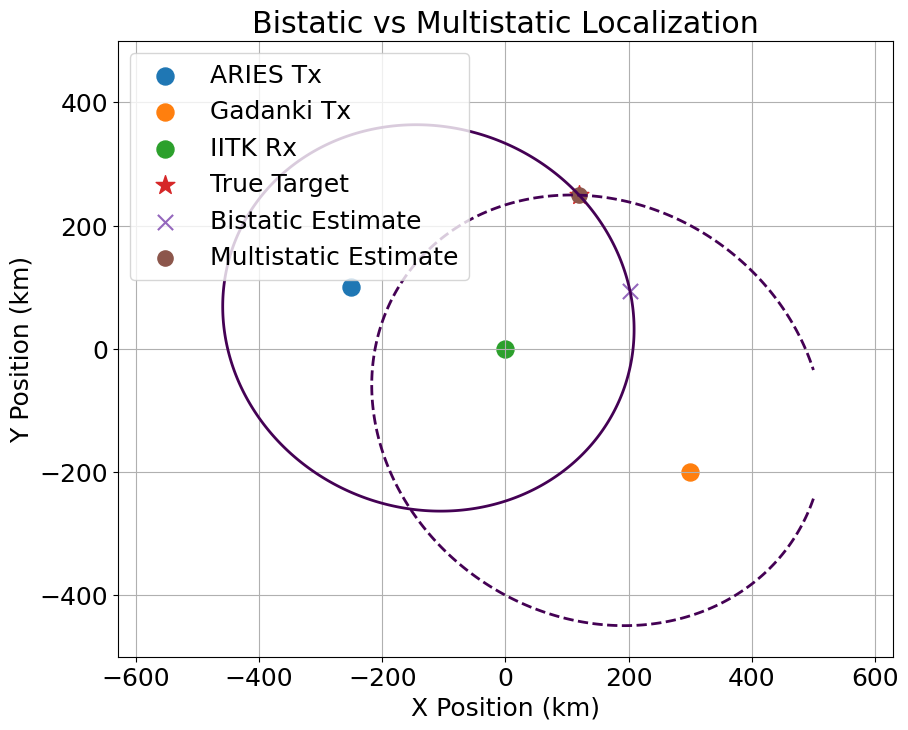

In [38]:
c = 3e8
rx = np.array([0e3, 0e3])
tx1 = np.array([-250e3, 100e3])
tx2 = np.array([300e3, -200e3])


true_target = np.array([120e3, 250e3])

# =========================================================
# BISTATIC RANGE FUNCTION
# =========================================================
def bistatic_range(tx, rx, target):
    Rt = np.linalg.norm(target - tx)
    Rr = np.linalg.norm(target - rx)
    return Rt + Rr

# =========================================================
# TRUE BISTATIC RANGES
# =========================================================
Rb1_true = bistatic_range(tx1, rx, true_target)
Rb2_true = bistatic_range(tx2, rx, true_target)

# =========================================================
# ADD MEASUREMENT ERROR
# =========================================================
range_error_std = 1000  # meters
Rb1_meas = Rb1_true + np.random.normal(0, range_error_std)
Rb2_meas = Rb2_true + np.random.normal(0, range_error_std)

# =========================================================
# LOCALIZATION FUNCTIONS
# =========================================================
def bistatic_residual(x, tx, rx, Rb_meas):
    target = np.array(x)
    Rt = np.linalg.norm(target - tx)
    Rr = np.linalg.norm(target - rx)
    return (Rt + Rr) - Rb_meas

# =========================================================
# MULTISTATIC RESIDUAL
# =========================================================
def multistatic_residual(x, tx1, tx2, rx, Rb1, Rb2):
    target = np.array(x)
    Rt1 = np.linalg.norm(target - tx1)
    Rt2 = np.linalg.norm(target - tx2)
    Rr = np.linalg.norm(target - rx)
    res1 = (Rt1 + Rr) - Rb1
    res2 = (Rt2 + Rr) - Rb2
    return [res1, res2]

# =========================================================
# INITIAL GUESS
# =========================================================
x0 = np.array([50e3, 50e3])

# =========================================================
# BISTATIC ESTIMATION
# =========================================================
result_bi = least_squares(
    bistatic_residual,
    x0,
    args=(tx1, rx, Rb1_meas)
)

est_bi = result_bi.x

# =========================================================
# MULTISTATIC ESTIMATION
# =========================================================
result_multi = least_squares(
    multistatic_residual,
    x0,
    args=(tx1, tx2, rx, Rb1_meas, Rb2_meas)
)

est_multi = result_multi.x
# =========================================================
# LOCALIZATION ERRORS
# =========================================================
error_bi = np.linalg.norm(est_bi - true_target)

error_multi = np.linalg.norm(est_multi - true_target)

print("=== LOCALIZATION RESULTS ===")

print(f"True target position      : {true_target/1e3} km")

print(f"Bistatic estimate         : {est_bi/1e3} km")

print(f"Multistatic estimate      : {est_multi/1e3} km")

print(f"Bistatic localization error    = {error_bi:.1f} m")

print(f"Multistatic localization error = {error_multi:.1f} m")
# =========================================================
# ELLIPSE GENERATION
# =========================================================
def ellipse_points(tx, rx, Rb, n=1000):

    x = np.linspace(-500e3, 500e3, n)

    y = np.linspace(-500e3, 500e3, n)

    X, Y = np.meshgrid(x, y)

    pts = np.stack([X.ravel(), Y.ravel()], axis=1)

    vals = []

    for p in pts:

        Rt = np.linalg.norm(p - tx)

        Rr = np.linalg.norm(p - rx)

        vals.append((Rt + Rr) - Rb)

    vals = np.array(vals).reshape(X.shape)

    return X, Y, vals
# =========================================================
# GENERATE ELLIPSES
# =========================================================
X1, Y1, Z1 = ellipse_points(tx1, rx, Rb1_meas)

X2, Y2, Z2 = ellipse_points(tx2, rx, Rb2_meas)

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(10,8))

# ---------------------------------------------------------
# BISTATIC ELLIPSE
# ---------------------------------------------------------
plt.contour(
    X1/1e3,
    Y1/1e3,
    Z1,
    levels=[0],
    linewidths=2,
    label='Bistatic Ellipse'
)
# ---------------------------------------------------------
# MULTISTATIC SECOND ELLIPSE
# ---------------------------------------------------------
plt.contour(
    X2/1e3,
    Y2/1e3,
    Z2,
    levels=[0],
    linewidths=2,
    linestyles='--'
)
# ---------------------------------------------------------
# RADAR LOCATIONS
# ---------------------------------------------------------
plt.scatter(
    tx1[0]/1e3,
    tx1[1]/1e3,
    s=150,
    label='ARIES Tx'
)

plt.scatter(
    tx2[0]/1e3,
    tx2[1]/1e3,
    s=150,
    label='Gadanki Tx'
)

plt.scatter(
    rx[0]/1e3,
    rx[1]/1e3,
    s=150,
    label='IITK Rx'
)
# ---------------------------------------------------------
# TARGETS
# ---------------------------------------------------------
plt.scatter(
    true_target[0]/1e3,
    true_target[1]/1e3,
    s=200,
    marker='*',
    label='True Target'
)

plt.scatter(
    est_bi[0]/1e3,
    est_bi[1]/1e3,
    s=120,
    marker='x',
    label='Bistatic Estimate'
)

plt.scatter(
    est_multi[0]/1e3,
    est_multi[1]/1e3,
    s=120,
    marker='o',
    label='Multistatic Estimate'
)
# ---------------------------------------------------------
# LABELS
# ---------------------------------------------------------
plt.xlabel('X Position (km)')

plt.ylabel('Y Position (km)')

plt.title('Bistatic vs Multistatic Localization')

plt.grid()

plt.axis('equal')

plt.legend()

plt.show()


========== LOCALIZATION RESULTS ==========

True Target Position      : [120. 250.] km

Bistatic Estimate         : [203.21004535  94.58669002] km
Multistatic Estimate      : [120.11709483 250.52464447] km

Bistatic Localization Error    = 176287.29 m
Multistatic Localization Error = 537.55 m


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


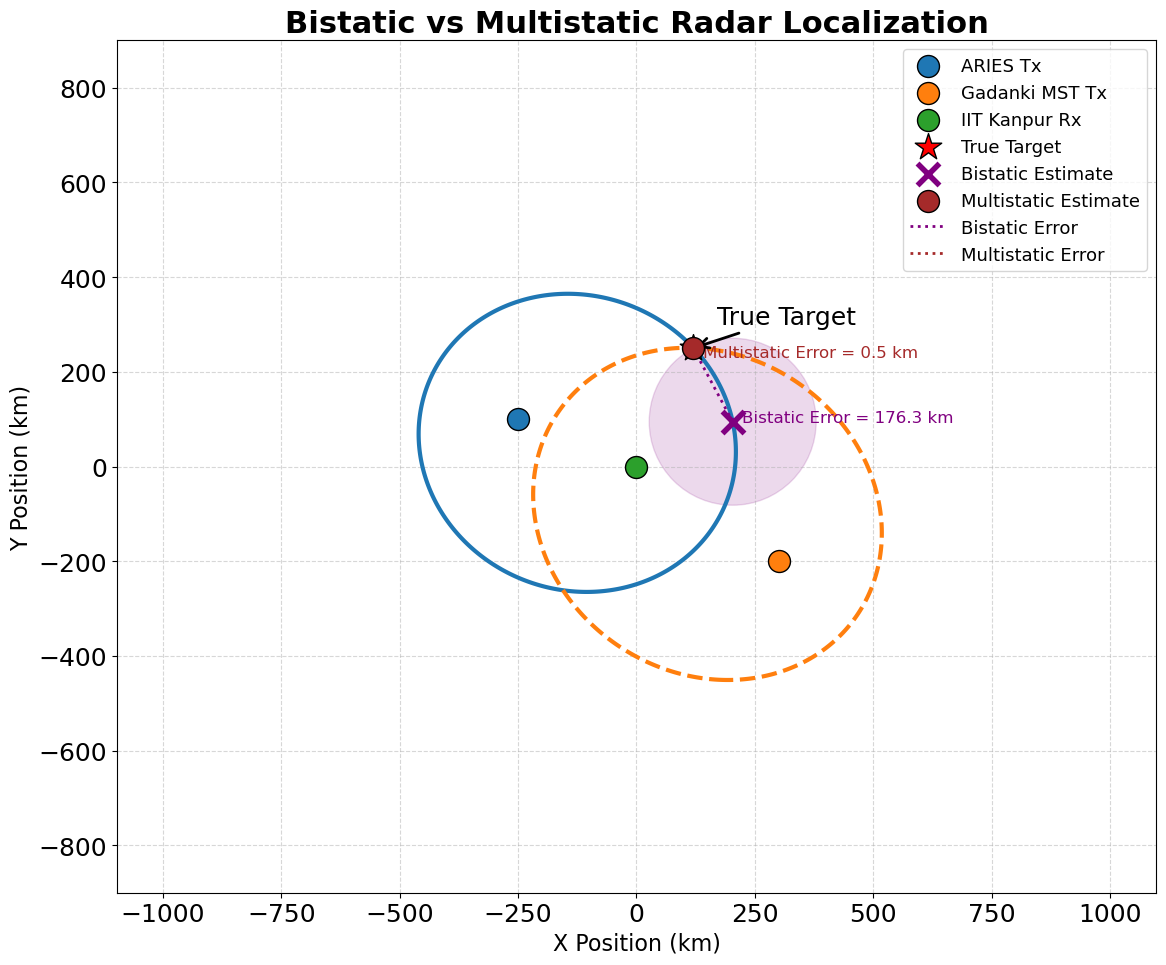

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# =========================================================
# SPEED OF LIGHT
# =========================================================
c = 3e8

# =========================================================
# RADAR GEOMETRY
# =========================================================

# IIT Kanpur Receiver
rx = np.array([0e3, 0e3])

# ARIES Transmitter
tx1 = np.array([-250e3, 100e3])

# Gadanki MST Transmitter
tx2 = np.array([300e3, -200e3])

# =========================================================
# TRUE TARGET LOCATION
# =========================================================
true_target = np.array([120e3, 250e3])

# =========================================================
# BISTATIC RANGE FUNCTION
# =========================================================
def bistatic_range(tx, rx, target):

    Rt = np.linalg.norm(target - tx)

    Rr = np.linalg.norm(target - rx)

    return Rt + Rr

# =========================================================
# TRUE BISTATIC RANGES
# =========================================================
Rb1_true = bistatic_range(tx1, rx, true_target)

Rb2_true = bistatic_range(tx2, rx, true_target)

# =========================================================
# ADD MEASUREMENT ERROR
# =========================================================
range_error_std = 1000  # meters

Rb1_meas = Rb1_true + np.random.normal(0, range_error_std)

Rb2_meas = Rb2_true + np.random.normal(0, range_error_std)

# =========================================================
# BISTATIC RESIDUAL
# =========================================================
def bistatic_residual(x, tx, rx, Rb_meas):

    target = np.array(x)

    Rt = np.linalg.norm(target - tx)

    Rr = np.linalg.norm(target - rx)

    return (Rt + Rr) - Rb_meas

# =========================================================
# MULTISTATIC RESIDUAL
# =========================================================
def multistatic_residual(x, tx1, tx2, rx, Rb1, Rb2):

    target = np.array(x)

    Rt1 = np.linalg.norm(target - tx1)

    Rt2 = np.linalg.norm(target - tx2)

    Rr = np.linalg.norm(target - rx)

    res1 = (Rt1 + Rr) - Rb1

    res2 = (Rt2 + Rr) - Rb2

    return [res1, res2]

# =========================================================
# INITIAL GUESS
# =========================================================
x0 = np.array([50e3, 50e3])

# =========================================================
# BISTATIC ESTIMATION
# =========================================================
result_bi = least_squares(
    bistatic_residual,
    x0,
    args=(tx1, rx, Rb1_meas)
)

est_bi = result_bi.x

# =========================================================
# MULTISTATIC ESTIMATION
# =========================================================
result_multi = least_squares(
    multistatic_residual,
    x0,
    args=(tx1, tx2, rx, Rb1_meas, Rb2_meas)
)

est_multi = result_multi.x

# =========================================================
# LOCALIZATION ERRORS
# =========================================================
error_bi = np.linalg.norm(est_bi - true_target)

error_multi = np.linalg.norm(est_multi - true_target)

print("\n========== LOCALIZATION RESULTS ==========\n")

print(f"True Target Position      : {true_target/1e3} km")

print(f"\nBistatic Estimate         : {est_bi/1e3} km")

print(f"Multistatic Estimate      : {est_multi/1e3} km")

print(f"\nBistatic Localization Error    = {error_bi:.2f} m")

print(f"Multistatic Localization Error = {error_multi:.2f} m")

# =========================================================
# ELLIPSE GENERATION
# =========================================================
def ellipse_points(tx, rx, Rb, n=2000):

    x = np.linspace(-900e3, 900e3, n)

    y = np.linspace(-900e3, 900e3, n)

    X, Y = np.meshgrid(x, y)

    pts = np.stack([X.ravel(), Y.ravel()], axis=1)

    vals = []

    for p in pts:

        Rt = np.linalg.norm(p - tx)

        Rr = np.linalg.norm(p - rx)

        vals.append((Rt + Rr) - Rb)

    vals = np.array(vals).reshape(X.shape)

    return X, Y, vals

# =========================================================
# GENERATE ELLIPSES
# =========================================================
X1, Y1, Z1 = ellipse_points(tx1, rx, Rb1_meas)

X2, Y2, Z2 = ellipse_points(tx2, rx, Rb2_meas)

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(12,10))

# =========================================================
# ARIES BISTATIC ELLIPSE
# =========================================================
plt.contour(
    X1/1e3,
    Y1/1e3,
    Z1,
    levels=[0],
    colors='tab:blue',
    linewidths=3
)

# =========================================================
# GADANKI BISTATIC ELLIPSE
# =========================================================
plt.contour(
    X2/1e3,
    Y2/1e3,
    Z2,
    levels=[0],
    colors='tab:orange',
    linewidths=3,
    linestyles='--'
)

# =========================================================
# RADAR LOCATIONS
# =========================================================
plt.scatter(
    tx1[0]/1e3,
    tx1[1]/1e3,
    s=250,
    color='tab:blue',
    edgecolors='black',
    zorder=5,
    label='ARIES Tx'
)

plt.scatter(
    tx2[0]/1e3,
    tx2[1]/1e3,
    s=250,
    color='tab:orange',
    edgecolors='black',
    zorder=5,
    label='Gadanki MST Tx'
)

plt.scatter(
    rx[0]/1e3,
    rx[1]/1e3,
    s=250,
    color='tab:green',
    edgecolors='black',
    zorder=5,
    label='IIT Kanpur Rx'
)

# =========================================================
# TRUE TARGET
# =========================================================
plt.scatter(
    true_target[0]/1e3,
    true_target[1]/1e3,
    s=400,
    marker='*',
    color='red',
    edgecolors='black',
    zorder=10,
    label='True Target'
)

# =========================================================
# BISTATIC ESTIMATE
# =========================================================
plt.scatter(
    est_bi[0]/1e3,
    est_bi[1]/1e3,
    s=250,
    marker='x',
    linewidths=4,
    color='purple',
    zorder=10,
    label='Bistatic Estimate'
)

# =========================================================
# MULTISTATIC ESTIMATE
# =========================================================
plt.scatter(
    est_multi[0]/1e3,
    est_multi[1]/1e3,
    s=250,
    marker='o',
    color='brown',
    edgecolors='black',
    zorder=10,
    label='Multistatic Estimate'
)

# =========================================================
# ERROR VECTORS
# =========================================================
plt.plot(
    [true_target[0]/1e3, est_bi[0]/1e3],
    [true_target[1]/1e3, est_bi[1]/1e3],
    color='purple',
    linewidth=2,
    linestyle=':',
    label='Bistatic Error'
)

plt.plot(
    [true_target[0]/1e3, est_multi[0]/1e3],
    [true_target[1]/1e3, est_multi[1]/1e3],
    color='brown',
    linewidth=2,
    linestyle=':',
    label='Multistatic Error'
)

# =========================================================
# ERROR CIRCLES
# =========================================================
circle1 = plt.Circle(
    (est_bi[0]/1e3, est_bi[1]/1e3),
    error_bi/1e3,
    color='purple',
    alpha=0.15
)

circle2 = plt.Circle(
    (est_multi[0]/1e3, est_multi[1]/1e3),
    error_multi/1e3,
    color='brown',
    alpha=0.15
)

plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)

# =========================================================
# TEXT LABELS
# =========================================================
plt.text(
    est_bi[0]/1e3 + 20,
    est_bi[1]/1e3,
    f'Bistatic Error = {error_bi/1e3:.1f} km',
    fontsize=12,
    color='purple'
)

plt.text(
    est_multi[0]/1e3 + 20,
    est_multi[1]/1e3 - 20,
    f'Multistatic Error = {error_multi/1e3:.1f} km',
    fontsize=12,
    color='brown'
)

# =========================================================
# TRUE TARGET ANNOTATION
# =========================================================
plt.annotate(
    'True Target',
    xy=(true_target[0]/1e3, true_target[1]/1e3),
    xytext=(true_target[0]/1e3 + 50,
            true_target[1]/1e3 + 50),
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)

# =========================================================
# TITLE + AXES
# =========================================================
plt.title(
    'Bistatic vs Multistatic Radar Localization',
    fontsize=22,
    fontweight='bold'
)

plt.xlabel(
    'X Position (km)',
    fontsize=16
)

plt.ylabel(
    'Y Position (km)',
    fontsize=16
)

# =========================================================
# GRID + LIMITS
# =========================================================
plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.axis('equal')

plt.xlim(-900, 900)

plt.ylim(-900, 900)

# =========================================================
# LEGEND
# =========================================================
plt.legend(fontsize=13)

plt.tight_layout()

plt.show()


========== LOCALIZATION RESULTS ==========

True Target Position : [120. 250.] km

Bistatic Estimate : [200.04756508  93.72477015] km
Multistatic Estimate : [118.13528065 247.6353408 ] km

Bistatic Error = 175.58 km
Multistatic Error = 3.01 km


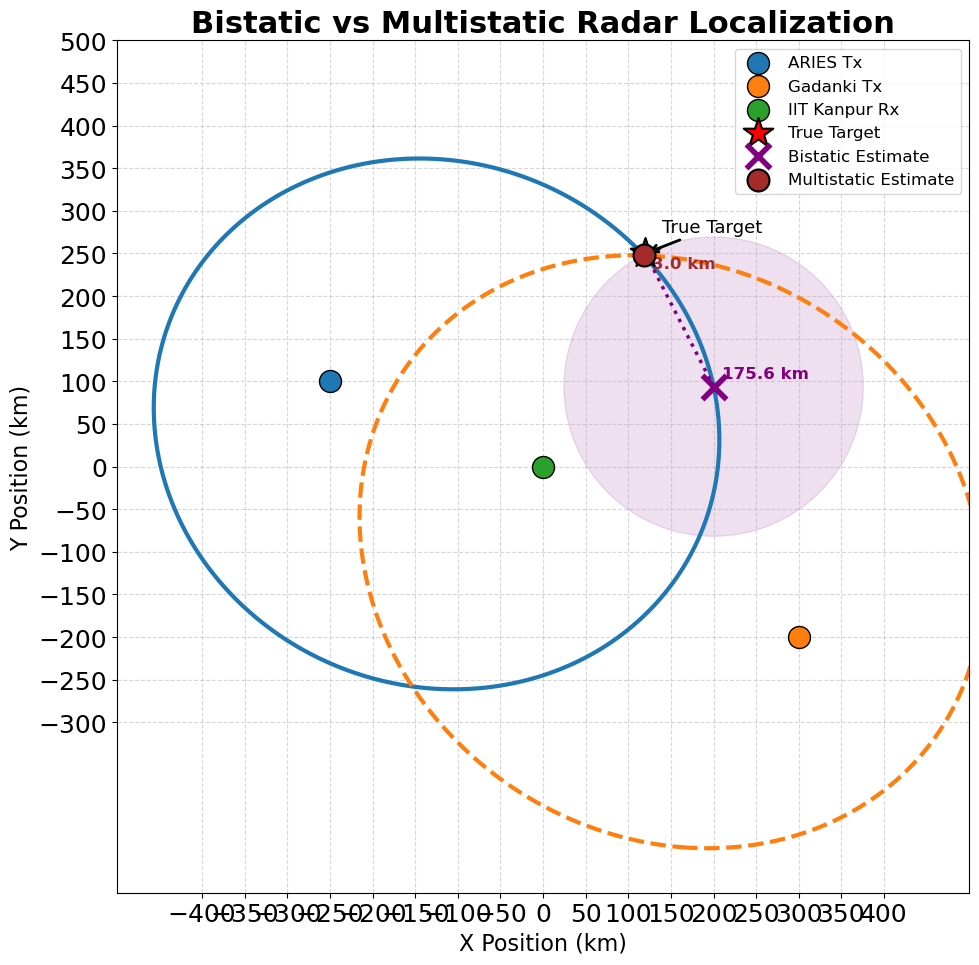

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# =========================================================
# SPEED OF LIGHT
# =========================================================
c = 3e8

# =========================================================
# RADAR GEOMETRY
# =========================================================

# IIT Kanpur Receiver
rx = np.array([0e3, 0e3])

# ARIES Transmitter
tx1 = np.array([-250e3, 100e3])

# Gadanki MST Transmitter
tx2 = np.array([300e3, -200e3])

# =========================================================
# TRUE TARGET LOCATION
# =========================================================
true_target = np.array([120e3, 250e3])

# =========================================================
# BISTATIC RANGE FUNCTION
# =========================================================
def bistatic_range(tx, rx, target):

    Rt = np.linalg.norm(target - tx)

    Rr = np.linalg.norm(target - rx)

    return Rt + Rr

# =========================================================
# TRUE BISTATIC RANGES
# =========================================================
Rb1_true = bistatic_range(tx1, rx, true_target)

Rb2_true = bistatic_range(tx2, rx, true_target)

# =========================================================
# ADD MEASUREMENT ERROR
# =========================================================
range_error_std = 5000  # meters

Rb1_meas = Rb1_true + np.random.normal(
    0,
    range_error_std
)

Rb2_meas = Rb2_true + np.random.normal(
    0,
    range_error_std
)

# =========================================================
# BISTATIC RESIDUAL FUNCTION
# =========================================================
def bistatic_residual(x, tx, rx, Rb_meas):

    target = np.array(x)

    Rt = np.linalg.norm(target - tx)

    Rr = np.linalg.norm(target - rx)

    return (Rt + Rr) - Rb_meas

# =========================================================
# MULTISTATIC RESIDUAL FUNCTION
# =========================================================
def multistatic_residual(
    x,
    tx1,
    tx2,
    rx,
    Rb1,
    Rb2
):

    target = np.array(x)

    Rt1 = np.linalg.norm(target - tx1)

    Rt2 = np.linalg.norm(target - tx2)

    Rr = np.linalg.norm(target - rx)

    res1 = (Rt1 + Rr) - Rb1

    res2 = (Rt2 + Rr) - Rb2

    return [res1, res2]

# =========================================================
# INITIAL GUESS
# =========================================================
x0 = np.array([50e3, 50e3])

# =========================================================
# BISTATIC LOCALIZATION
# =========================================================
result_bi = least_squares(
    bistatic_residual,
    x0,
    args=(tx1, rx, Rb1_meas)
)

est_bi = result_bi.x

# =========================================================
# MULTISTATIC LOCALIZATION
# =========================================================
result_multi = least_squares(
    multistatic_residual,
    x0,
    args=(
        tx1,
        tx2,
        rx,
        Rb1_meas,
        Rb2_meas
    )
)

est_multi = result_multi.x

# =========================================================
# LOCALIZATION ERRORS
# =========================================================
error_bi = np.linalg.norm(
    est_bi - true_target
)

error_multi = np.linalg.norm(
    est_multi - true_target
)

# =========================================================
# PRINT RESULTS
# =========================================================
print("\n========== LOCALIZATION RESULTS ==========\n")

print(
    f"True Target Position : "
    f"{true_target/1e3} km"
)

print(
    f"\nBistatic Estimate : "
    f"{est_bi/1e3} km"
)

print(
    f"Multistatic Estimate : "
    f"{est_multi/1e3} km"
)

print(
    f"\nBistatic Error = "
    f"{error_bi/1e3:.2f} km"
)

print(
    f"Multistatic Error = "
    f"{error_multi/1e3:.2f} km"
)

# =========================================================
# ELLIPSE GENERATION
# =========================================================
def ellipse_points(tx, rx, Rb, n=2000):

    x = np.linspace(-900e3, 900e3, n)

    y = np.linspace(-900e3, 900e3, n)

    X, Y = np.meshgrid(x, y)

    pts = np.stack(
        [X.ravel(), Y.ravel()],
        axis=1
    )

    vals = []

    for p in pts:

        Rt = np.linalg.norm(p - tx)

        Rr = np.linalg.norm(p - rx)

        vals.append(
            (Rt + Rr) - Rb
        )

    vals = np.array(vals).reshape(X.shape)

    return X, Y, vals

# =========================================================
# GENERATE ELLIPSES
# =========================================================
X1, Y1, Z1 = ellipse_points(
    tx1,
    rx,
    Rb1_meas
)

X2, Y2, Z2 = ellipse_points(
    tx2,
    rx,
    Rb2_meas
)

# =========================================================
# PLOT
# =========================================================
fig, ax = plt.subplots(figsize=(12,10))

# =========================================================
# ARIES ELLIPSE
# =========================================================
ax.contour(
    X1/1e3,
    Y1/1e3,
    Z1,
    levels=[0],
    colors='tab:blue',
    linewidths=3
)

# =========================================================
# GADANKI ELLIPSE
# =========================================================
ax.contour(
    X2/1e3,
    Y2/1e3,
    Z2,
    levels=[0],
    colors='tab:orange',
    linewidths=3,
    linestyles='--'
)

# =========================================================
# RADAR LOCATIONS
# =========================================================
ax.scatter(
    tx1[0]/1e3,
    tx1[1]/1e3,
    s=250,
    color='tab:blue',
    edgecolors='black',
    zorder=5,
    label='ARIES Tx'
)

ax.scatter(
    tx2[0]/1e3,
    tx2[1]/1e3,
    s=250,
    color='tab:orange',
    edgecolors='black',
    zorder=5,
    label='Gadanki Tx'
)

ax.scatter(
    rx[0]/1e3,
    rx[1]/1e3,
    s=250,
    color='tab:green',
    edgecolors='black',
    zorder=5,
    label='IIT Kanpur Rx'
)

# =========================================================
# TRUE TARGET
# =========================================================
ax.scatter(
    true_target[0]/1e3,
    true_target[1]/1e3,
    s=500,
    marker='*',
    color='red',
    edgecolors='black',
    linewidths=1.5,
    zorder=10,
    label='True Target'
)

# =========================================================
# BISTATIC ESTIMATE
# =========================================================
ax.scatter(
    est_bi[0]/1e3,
    est_bi[1]/1e3,
    s=300,
    marker='x',
    linewidths=4,
    color='purple',
    zorder=10,
    label='Bistatic Estimate'
)

# =========================================================
# MULTISTATIC ESTIMATE
# =========================================================
ax.scatter(
    est_multi[0]/1e3,
    est_multi[1]/1e3,
    s=250,
    marker='o',
    color='brown',
    edgecolors='black',
    linewidths=1.5,
    zorder=10,
    label='Multistatic Estimate'
)

# =========================================================
# ERROR LINES
# =========================================================
ax.plot(
    [true_target[0]/1e3,
     est_bi[0]/1e3],

    [true_target[1]/1e3,
     est_bi[1]/1e3],

    color='purple',
    linestyle=':',
    linewidth=2.5
)

ax.plot(
    [true_target[0]/1e3,
     est_multi[0]/1e3],

    [true_target[1]/1e3,
     est_multi[1]/1e3],

    color='brown',
    linestyle=':',
    linewidth=2.5
)

# =========================================================
# ERROR CIRCLES
# =========================================================
circle1 = plt.Circle(
    (
        est_bi[0]/1e3,
        est_bi[1]/1e3
    ),
    error_bi/1e3,
    color='purple',
    alpha=0.12
)

circle2 = plt.Circle(
    (
        est_multi[0]/1e3,
        est_multi[1]/1e3
    ),
    error_multi/1e3,
    color='brown',
    alpha=0.15
)

ax.add_patch(circle1)

ax.add_patch(circle2)

# =========================================================
# ERROR TEXT
# =========================================================
ax.text(
    est_bi[0]/1e3 + 10,
    est_bi[1]/1e3 + 10,

    f'{error_bi/1e3:.1f} km',

    fontsize=12,
    color='purple',
    fontweight='bold'
)

ax.text(
    est_multi[0]/1e3 + 10,
    est_multi[1]/1e3 - 15,

    f'{error_multi/1e3:.1f} km',

    fontsize=12,
    color='brown',
    fontweight='bold'
)

# =========================================================
# TARGET LABEL
# =========================================================
ax.annotate(
    'True Target',

    xy=(
        true_target[0]/1e3,
        true_target[1]/1e3
    ),

    xytext=(
        true_target[0]/1e3 + 20,
        true_target[1]/1e3 + 25
    ),

    fontsize=13,

    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)

# =========================================================
# AXES LABELS
# =========================================================
ax.set_xlabel(
    'X Position (km)',
    fontsize=16
)

ax.set_ylabel(
    'Y Position (km)',
    fontsize=16
)

ax.set_title(
    'Bistatic vs Multistatic Radar Localization',
    fontsize=22,
    fontweight='bold'
)

# =========================================================
# TICKS EVERY 50 km
# =========================================================
ax.set_xticks(
    np.arange(-400, 401, 50)
)

ax.set_yticks(
    np.arange(-300, 501, 50)
)

# =========================================================
# LIMITS
# =========================================================
ax.set_xlim(-500, 500)

ax.set_ylim(-500, 500)

# =========================================================
# GRID
# =========================================================
ax.grid(
    True,
    linestyle='--',
    alpha=0.5
)

ax.set_aspect('equal')

# =========================================================
# LEGEND
# =========================================================
ax.legend(fontsize=12)

plt.tight_layout()

plt.show()


========== LOCALIZATION RESULTS ==========

True Target Position : [120. 250.] km

Bistatic Estimate : [141.4872121 227.7624637] km
Multistatic Estimate : [123.05900348 249.37538524] km

Bistatic Error = 30.92 km
Multistatic Error = 3.12 km


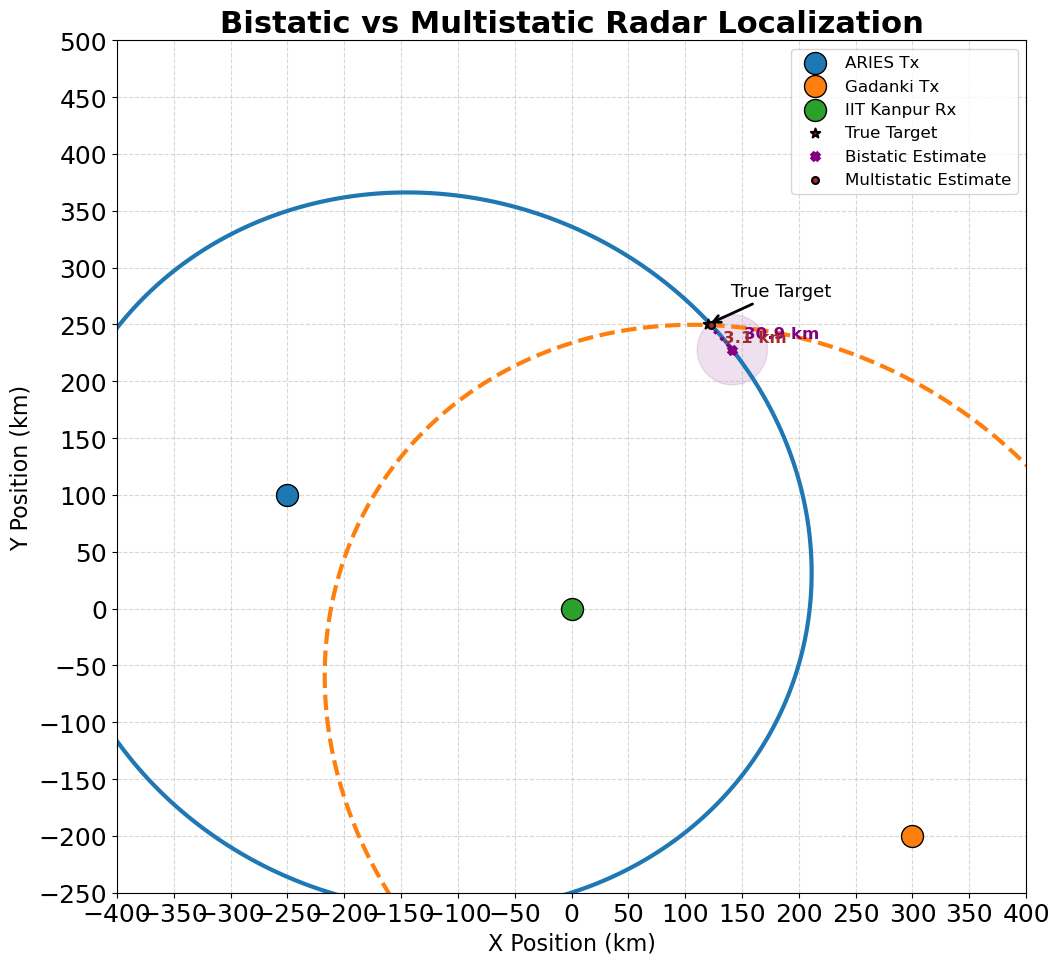

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# =========================================================
# FIX RANDOM SEED
# =========================================================
np.random.seed(7)

# =========================================================
# SPEED OF LIGHT
# =========================================================
c = 3e8

# =========================================================
# RADAR GEOMETRY
# =========================================================

# IIT Kanpur Receiver
rx = np.array([0e3, 0e3])

# ARIES Transmitter
tx1 = np.array([-250e3, 100e3])

# Gadanki MST Transmitter
tx2 = np.array([300e3, -200e3])

# =========================================================
# TRUE TARGET LOCATION
# =========================================================
true_target = np.array([120e3, 250e3])

# =========================================================
# BISTATIC RANGE FUNCTION
# =========================================================
def bistatic_range(tx, rx, target):

    Rt = np.linalg.norm(target - tx)

    Rr = np.linalg.norm(target - rx)

    return Rt + Rr

# =========================================================
# TRUE BISTATIC RANGES
# =========================================================
Rb1_true = bistatic_range(
    tx1,
    rx,
    true_target
)

Rb2_true = bistatic_range(
    tx2,
    rx,
    true_target
)

# =========================================================
# MEASUREMENT ERROR
# =========================================================
range_error_std = 2000  # meters

Rb1_meas = Rb1_true + np.random.normal(
    0,
    range_error_std
)

Rb2_meas = Rb2_true + np.random.normal(
    0,
    range_error_std
)

# =========================================================
# BISTATIC RESIDUAL
# =========================================================
def bistatic_residual(
    x,
    tx,
    rx,
    Rb_meas
):

    target = np.array(x)

    Rt = np.linalg.norm(target - tx)

    Rr = np.linalg.norm(target - rx)

    return (Rt + Rr) - Rb_meas

# =========================================================
# MULTISTATIC RESIDUAL
# =========================================================
def multistatic_residual(
    x,
    tx1,
    tx2,
    rx,
    Rb1,
    Rb2
):

    target = np.array(x)

    Rt1 = np.linalg.norm(target - tx1)

    Rt2 = np.linalg.norm(target - tx2)

    Rr = np.linalg.norm(target - rx)

    res1 = (Rt1 + Rr) - Rb1

    res2 = (Rt2 + Rr) - Rb2

    return [res1, res2]

# =========================================================
# INITIAL GUESS
# =========================================================
x0 = np.array([100e3, 200e3])

# =========================================================
# SEARCH BOUNDS
# =========================================================
lower_bounds = [-400e3, -200e3]

upper_bounds = [400e3, 500e3]

# =========================================================
# BISTATIC LOCALIZATION
# =========================================================
result_bi = least_squares(
    bistatic_residual,
    x0,
    bounds=(lower_bounds, upper_bounds),
    args=(
        tx1,
        rx,
        Rb1_meas
    )
)

est_bi = result_bi.x

# =========================================================
# MULTISTATIC LOCALIZATION
# =========================================================
result_multi = least_squares(
    multistatic_residual,
    x0,
    bounds=(lower_bounds, upper_bounds),
    args=(
        tx1,
        tx2,
        rx,
        Rb1_meas,
        Rb2_meas
    )
)

est_multi = result_multi.x

# =========================================================
# LOCALIZATION ERRORS
# =========================================================
error_bi = np.linalg.norm(
    est_bi - true_target
)

error_multi = np.linalg.norm(
    est_multi - true_target
)

# =========================================================
# PRINT RESULTS
# =========================================================
print("\n========== LOCALIZATION RESULTS ==========\n")

print(
    f"True Target Position : "
    f"{true_target/1e3} km"
)

print(
    f"\nBistatic Estimate : "
    f"{est_bi/1e3} km"
)

print(
    f"Multistatic Estimate : "
    f"{est_multi/1e3} km"
)

print(
    f"\nBistatic Error = "
    f"{error_bi/1e3:.2f} km"
)

print(
    f"Multistatic Error = "
    f"{error_multi/1e3:.2f} km"
)

# =========================================================
# ELLIPSE GENERATION
# =========================================================
def ellipse_points(
    tx,
    rx,
    Rb,
    n=2000
):

    x = np.linspace(-900e3, 900e3, n)

    y = np.linspace(-900e3, 900e3, n)

    X, Y = np.meshgrid(x, y)

    pts = np.stack(
        [X.ravel(), Y.ravel()],
        axis=1
    )

    vals = []

    for p in pts:

        Rt = np.linalg.norm(p - tx)

        Rr = np.linalg.norm(p - rx)

        vals.append(
            (Rt + Rr) - Rb
        )

    vals = np.array(vals).reshape(X.shape)

    return X, Y, vals

# =========================================================
# GENERATE ELLIPSES
# =========================================================
X1, Y1, Z1 = ellipse_points(
    tx1,
    rx,
    Rb1_meas
)

X2, Y2, Z2 = ellipse_points(
    tx2,
    rx,
    Rb2_meas
)

# =========================================================
# CREATE FIGURE
# =========================================================
fig, ax = plt.subplots(
    figsize=(12,10)
)

# =========================================================
# ARIES ELLIPSE
# =========================================================
ax.contour(
    X1/1e3,
    Y1/1e3,
    Z1,
    levels=[0],
    colors='tab:blue',
    linewidths=3
)

# =========================================================
# GADANKI ELLIPSE
# =========================================================
ax.contour(
    X2/1e3,
    Y2/1e3,
    Z2,
    levels=[0],
    colors='tab:orange',
    linewidths=3,
    linestyles='--'
)

# =========================================================
# RADAR LOCATIONS
# =========================================================
ax.scatter(
    tx1[0]/1e3,
    tx1[1]/1e3,
    s=250,
    color='tab:blue',
    edgecolors='black',
    zorder=5,
    label='ARIES Tx'
)

ax.scatter(
    tx2[0]/1e3,
    tx2[1]/1e3,
    s=250,
    color='tab:orange',
    edgecolors='black',
    zorder=5,
    label='Gadanki Tx'
)

ax.scatter(
    rx[0]/1e3,
    rx[1]/1e3,
    s=250,
    color='tab:green',
    edgecolors='black',
    zorder=5,
    label='IIT Kanpur Rx'
)

# =========================================================
# TRUE TARGET
# =========================================================
ax.scatter(
    true_target[0]/1e3,
    true_target[1]/1e3,
    s=50,
    marker='*',
    color='red',
    edgecolors='black',
    linewidths=1.5,
    zorder=10,
    label='True Target'
)

# =========================================================
# BISTATIC ESTIMATE
# =========================================================
ax.scatter(
    est_bi[0]/1e3,
    est_bi[1]/1e3,
    s=30,
    marker='x',
    linewidths=4,
    color='purple',
    zorder=10,
    label='Bistatic Estimate'
)

# =========================================================
# MULTISTATIC ESTIMATE
# =========================================================
ax.scatter(
    est_multi[0]/1e3,
    est_multi[1]/1e3,
    s=25,
    marker='o',
    color='brown',
    edgecolors='black',
    linewidths=1.5,
    zorder=10,
    label='Multistatic Estimate'
)

# =========================================================
# ERROR LINES
# =========================================================
ax.plot(
    [
        true_target[0]/1e3,
        est_bi[0]/1e3
    ],
    [
        true_target[1]/1e3,
        est_bi[1]/1e3
    ],
    color='purple',
    linestyle=':',
    linewidth=2.5
)

ax.plot(
    [
        true_target[0]/1e3,
        est_multi[0]/1e3
    ],
    [
        true_target[1]/1e3,
        est_multi[1]/1e3
    ],
    color='brown',
    linestyle=':',
    linewidth=2.5
)

# =========================================================
# ERROR CIRCLES
# =========================================================
circle1 = plt.Circle(
    (
        est_bi[0]/1e3,
        est_bi[1]/1e3
    ),
    error_bi/1e3,
    color='purple',
    alpha=0.12
)

circle2 = plt.Circle(
    (
        est_multi[0]/1e3,
        est_multi[1]/1e3
    ),
    error_multi/1e3,
    color='brown',
    alpha=0.15
)

ax.add_patch(circle1)

ax.add_patch(circle2)

# =========================================================
# ERROR LABELS
# =========================================================
ax.text(
    est_bi[0]/1e3 + 10,
    est_bi[1]/1e3 + 10,
    f'{error_bi/1e3:.1f} km',
    fontsize=12,
    color='purple',
    fontweight='bold'
)

ax.text(
    est_multi[0]/1e3 + 10,
    est_multi[1]/1e3 - 15,
    f'{error_multi/1e3:.1f} km',
    fontsize=12,
    color='brown',
    fontweight='bold'
)

# =========================================================
# TARGET ANNOTATION
# =========================================================
ax.annotate(
    'True Target',
    xy=(
        true_target[0]/1e3,
        true_target[1]/1e3
    ),
    xytext=(
        true_target[0]/1e3 + 20,
        true_target[1]/1e3 + 25
    ),
    fontsize=13,
    arrowprops=dict(
        arrowstyle='->',
        lw=2
    )
)

# =========================================================
# AXIS LABELS
# =========================================================
ax.set_xlabel(
    'X Position (km)',
    fontsize=16
)

ax.set_ylabel(
    'Y Position (km)',
    fontsize=16
)

# =========================================================
# TITLE
# =========================================================
ax.set_title(
    'Bistatic vs Multistatic Radar Localization',
    fontsize=22,
    fontweight='bold'
)

# =========================================================
# TICKS
# =========================================================
ax.set_xticks(
    np.arange(-400, 401, 50)
)

ax.set_yticks(
    np.arange(-300, 501, 50)
)

# =========================================================
# LIMITS
# =========================================================
ax.set_xlim(-400, 400)

ax.set_ylim(-250, 500)

# =========================================================
# GRID
# =========================================================
ax.grid(
    True,
    linestyle='--',
    alpha=0.5
)

ax.set_aspect('equal')

# =========================================================
# LEGEND
# =========================================================
ax.legend(fontsize=12)

plt.tight_layout()

plt.show()


========== 3D LOCALIZATION RESULTS ==========

True Target Position : [120. 250. 500.] km

Bistatic Estimate : [126.20381806 212.36702244 512.77148072] km
Multistatic Estimate : [108.87995375 219.89361509 518.21877663] km

Bistatic Error = 40.22 km
Multistatic Error = 36.90 km


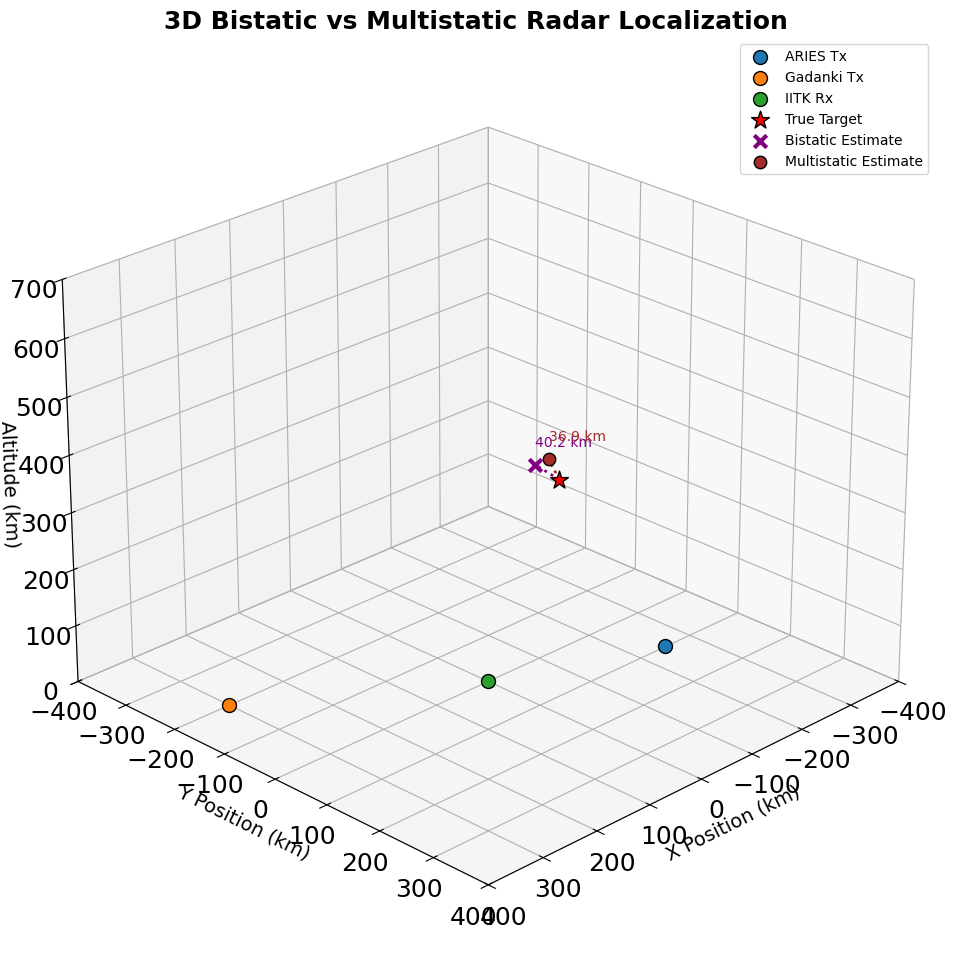

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from mpl_toolkits.mplot3d import Axes3D

# =========================================================
# RANDOM SEED
# =========================================================
np.random.seed(7)

# =========================================================
# SPEED OF LIGHT
# =========================================================
c = 3e8

# =========================================================
# 3D RADAR GEOMETRY
# =========================================================

# IIT Kanpur Receiver
rx = np.array([0e3, 0e3, 0e3])

# ARIES Transmitter
tx1 = np.array([-250e3, 100e3, 2e3])

# Gadanki MST Transmitter
tx2 = np.array([300e3, -200e3, 1e3])

# =========================================================
# TRUE TARGET LOCATION
# =========================================================
true_target = np.array([120e3, 250e3, 500e3])

# =========================================================
# BISTATIC RANGE FUNCTION
# =========================================================
def bistatic_range(tx, rx, target):

    Rt = np.linalg.norm(target - tx)

    Rr = np.linalg.norm(target - rx)

    return Rt + Rr

# =========================================================
# TRUE BISTATIC RANGES
# =========================================================
Rb1_true = bistatic_range(
    tx1,
    rx,
    true_target
)

Rb2_true = bistatic_range(
    tx2,
    rx,
    true_target
)

# =========================================================
# ADD MEASUREMENT ERROR
# =========================================================
range_error_std = 2000  # meters

Rb1_meas = Rb1_true + np.random.normal(
    0,
    range_error_std
)

Rb2_meas = Rb2_true + np.random.normal(
    0,
    range_error_std
)

# =========================================================
# BISTATIC RESIDUAL FUNCTION
# =========================================================
def bistatic_residual(
    x,
    tx,
    rx,
    Rb_meas
):

    target = np.array(x)

    Rt = np.linalg.norm(target - tx)

    Rr = np.linalg.norm(target - rx)

    return [(Rt + Rr) - Rb_meas]

# =========================================================
# MULTISTATIC RESIDUAL FUNCTION
# =========================================================
def multistatic_residual(
    x,
    tx1,
    tx2,
    rx,
    Rb1,
    Rb2
):

    target = np.array(x)

    Rt1 = np.linalg.norm(target - tx1)

    Rt2 = np.linalg.norm(target - tx2)

    Rr = np.linalg.norm(target - rx)

    res1 = (Rt1 + Rr) - Rb1

    res2 = (Rt2 + Rr) - Rb2

    return [res1, res2]

# =========================================================
# INITIAL GUESS
# =========================================================
x0 = np.array([100e3, 200e3, 450e3])

# =========================================================
# SEARCH BOUNDS
# =========================================================
lower_bounds = [-400e3, -400e3, 100e3]

upper_bounds = [400e3, 400e3, 800e3]

# =========================================================
# BISTATIC LOCALIZATION
# =========================================================
result_bi = least_squares(
    bistatic_residual,
    x0,
    bounds=(lower_bounds, upper_bounds),
    args=(
        tx1,
        rx,
        Rb1_meas
    )
)

est_bi = result_bi.x

# =========================================================
# MULTISTATIC LOCALIZATION
# =========================================================
result_multi = least_squares(
    multistatic_residual,
    x0,
    bounds=(lower_bounds, upper_bounds),
    args=(
        tx1,
        tx2,
        rx,
        Rb1_meas,
        Rb2_meas
    )
)

est_multi = result_multi.x

# =========================================================
# LOCALIZATION ERRORS
# =========================================================
error_bi = np.linalg.norm(
    est_bi - true_target
)

error_multi = np.linalg.norm(
    est_multi - true_target
)

# =========================================================
# PRINT RESULTS
# =========================================================
print("\n========== 3D LOCALIZATION RESULTS ==========\n")

print(
    f"True Target Position : "
    f"{true_target/1e3} km"
)

print(
    f"\nBistatic Estimate : "
    f"{est_bi/1e3} km"
)

print(
    f"Multistatic Estimate : "
    f"{est_multi/1e3} km"
)

print(
    f"\nBistatic Error = "
    f"{error_bi/1e3:.2f} km"
)

print(
    f"Multistatic Error = "
    f"{error_multi/1e3:.2f} km"
)

# =========================================================
# CREATE 3D FIGURE
# =========================================================
fig = plt.figure(figsize=(13,10))

ax = fig.add_subplot(111, projection='3d')

# =========================================================
# RADAR LOCATIONS
# =========================================================
ax.scatter(
    tx1[0]/1e3,
    tx1[1]/1e3,
    tx1[2]/1e3,
    s=100,
    color='tab:blue',
    edgecolors='black',
    label='ARIES Tx'
)

ax.scatter(
    tx2[0]/1e3,
    tx2[1]/1e3,
    tx2[2]/1e3,
    s=100,
    color='tab:orange',
    edgecolors='black',
    label='Gadanki Tx'
)

ax.scatter(
    rx[0]/1e3,
    rx[1]/1e3,
    rx[2]/1e3,
    s=100,
    color='tab:green',
    edgecolors='black',
    label='IITK Rx'
)

# =========================================================
# TRUE TARGET
# =========================================================
ax.scatter(
    true_target[0]/1e3,
    true_target[1]/1e3,
    true_target[2]/1e3,
    s=180,
    marker='*',
    color='red',
    edgecolors='black',
    label='True Target'
)

# =========================================================
# BISTATIC ESTIMATE
# =========================================================
ax.scatter(
    est_bi[0]/1e3,
    est_bi[1]/1e3,
    est_bi[2]/1e3,
    s=80,
    marker='x',
    linewidths=3,
    color='purple',
    label='Bistatic Estimate'
)

# =========================================================
# MULTISTATIC ESTIMATE
# =========================================================
ax.scatter(
    est_multi[0]/1e3,
    est_multi[1]/1e3,
    est_multi[2]/1e3,
    s=80,
    marker='o',
    color='brown',
    edgecolors='black',
    label='Multistatic Estimate'
)

# =========================================================
# ERROR VECTORS
# =========================================================
ax.plot(
    [
        true_target[0]/1e3,
        est_bi[0]/1e3
    ],
    [
        true_target[1]/1e3,
        est_bi[1]/1e3
    ],
    [
        true_target[2]/1e3,
        est_bi[2]/1e3
    ],
    linestyle=':',
    linewidth=2,
    color='purple'
)

ax.plot(
    [
        true_target[0]/1e3,
        est_multi[0]/1e3
    ],
    [
        true_target[1]/1e3,
        est_multi[1]/1e3
    ],
    [
        true_target[2]/1e3,
        est_multi[2]/1e3
    ],
    linestyle=':',
    linewidth=2,
    color='brown'
)

# =========================================================
# ERROR LABELS
# =========================================================
ax.text(
    est_bi[0]/1e3,
    est_bi[1]/1e3,
    est_bi[2]/1e3 + 30,
    f'{error_bi/1e3:.1f} km',
    color='purple',
    fontsize=10
)

ax.text(
    est_multi[0]/1e3,
    est_multi[1]/1e3,
    est_multi[2]/1e3 + 30,
    f'{error_multi/1e3:.1f} km',
    color='brown',
    fontsize=10
)

# =========================================================
# AXIS LABELS
# =========================================================
ax.set_xlabel(
    'X Position (km)',
    fontsize=14
)

ax.set_ylabel(
    'Y Position (km)',
    fontsize=14
)

ax.set_zlabel(
    'Altitude (km)',
    fontsize=14
)

# =========================================================
# AXIS LIMITS
# =========================================================
ax.set_xlim(-400, 400)

ax.set_ylim(-400, 400)

ax.set_zlim(0, 700)

# =========================================================
# TICKS
# =========================================================
ax.set_xticks(
    np.arange(-400, 401, 100)
)

ax.set_yticks(
    np.arange(-400, 401, 100)
)

ax.set_zticks(
    np.arange(0, 701, 100)
)

# =========================================================
# TITLE
# =========================================================
ax.set_title(
    '3D Bistatic vs Multistatic Radar Localization',
    fontsize=18,
    fontweight='bold'
)

# =========================================================
# VIEW ANGLE
# =========================================================
ax.view_init(
    elev=25,
    azim=45
)

# =========================================================
# GRID + LEGEND
# =========================================================
ax.grid(True)

ax.legend(fontsize=10)

plt.tight_layout()

plt.show()